# Project 1: Multi-Asset VaR & Stressed VaR Engine
**Target Role:** Market Risk Analytics Analyst, Morgan Stanley

This notebook implements a production-style market risk engine covering:
- **Historical Simulation VaR** (99%, 250-day rolling)
- **Stressed VaR** (Basel 2.5 methodology)
- **Monte Carlo VaR** (Normal + Student-t)
- **Liquidity-Adjusted VaR (LVaR)**
- **Basel Traffic-Light Backtesting** (Kupiec POF + Christoffersen independence)

---
### Setup
```
pip install yfinance fredapi pandas numpy scipy matplotlib
```
Get a free FRED API key at: https://fred.stlouisfed.org/docs/api/api_key.html

In [81]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy import stats
from scipy.stats import norm, t as studentt
import os

import yfinance as yf

# Optional: uncomment if you have a FRED key
# from fredapi import Fred

plt.rcParams['figure.facecolor'] = '#1a1a2e'
plt.rcParams['axes.facecolor']   = '#2d2d44'
plt.rcParams['axes.edgecolor']   = '#3a3a55'
plt.rcParams['text.color']       = '#e8e8e8'
plt.rcParams['xtick.color']      = '#a0a0b8'
plt.rcParams['ytick.color']      = '#a0a0b8'
plt.rcParams['grid.color']       = '#3a3a55'
plt.rcParams['grid.linewidth']   = 0.5

print('Libraries loaded.')

Libraries loaded.


## 1. Configuration

In [82]:
FRED_API_KEY = 'c24e83bc1962a55d1cee9d32936177a7'

PORTFOLIO = {
    'SPY': {'weight': 0.20, 'asset_class': 'Equity',    'name': 'S&P 500 ETF'},
    'QQQ': {'weight': 0.10, 'asset_class': 'Equity',    'name': 'Nasdaq 100 ETF'},
    'EEM': {'weight': 0.05, 'asset_class': 'EM Equity', 'name': 'EM Equity ETF'},
    'TLT': {'weight': 0.20, 'asset_class': 'Rates',     'name': '20yr Treasury ETF'},
    'LQD': {'weight': 0.10, 'asset_class': 'Credit',    'name': 'IG Corporate ETF'},
    'HYG': {'weight': 0.05, 'asset_class': 'Credit',    'name': 'HY Corporate ETF'},
    'GLD': {'weight': 0.15, 'asset_class': 'Commodity', 'name': 'Gold ETF'},
    'USO': {'weight': 0.10, 'asset_class': 'Commodity', 'name': 'Oil ETF'},
    'FXE': {'weight': 0.05, 'asset_class': 'FX',        'name': 'EUR/USD ETF'},
}

PORTFOLIO_VALUE  = 100_000_000
VAR_CONFIDENCE   = 0.99
HS_WINDOW        = 250
MC_SIMULATIONS   = 50_000
START_DATE       = '2005-01-01'
END_DATE         = '2024-12-31'
STRESS_START     = '2008-01-01'
STRESS_END       = '2008-12-31'

BID_ASK_SPREADS  = {'Equity': 0.005, 'EM Equity': 0.015, 'Rates': 0.003,
                    'Credit': 0.020, 'Commodity': 0.010, 'FX': 0.002}
LIQUIDATION_DAYS = {'Equity': 1, 'EM Equity': 3, 'Rates': 1,
                    'Credit': 5, 'Commodity': 2, 'FX': 1}

os.makedirs('output', exist_ok=True)
print('Config set. Portfolio:')
for t, v in PORTFOLIO.items():
    print(f"  {t:5s}  {v['weight']*100:5.1f}%  {v['asset_class']:12s}  {v['name']}")

Config set. Portfolio:
  SPY     20.0%  Equity        S&P 500 ETF
  QQQ     10.0%  Equity        Nasdaq 100 ETF
  EEM      5.0%  EM Equity     EM Equity ETF
  TLT     20.0%  Rates         20yr Treasury ETF
  LQD     10.0%  Credit        IG Corporate ETF
  HYG      5.0%  Credit        HY Corporate ETF
  GLD     15.0%  Commodity     Gold ETF
  USO     10.0%  Commodity     Oil ETF
  FXE      5.0%  FX            EUR/USD ETF


## 2. Data Acquisition
Downloads daily adjusted closing prices via `yfinance`.

**What yfinance fetches:** Yahoo Finance adjusted close prices, accounting for splits and dividends. For ETFs these are the cleanest proxies for asset class returns available for free.

In [83]:
tickers = list(PORTFOLIO.keys())
print(f'Fetching data for: {tickers}')

prices = yf.download(tickers, start=START_DATE, end=END_DATE,
                     auto_adjust=True, progress=True)['Close']
prices = prices.dropna(how='all')
prices.to_csv('output/prices_raw.csv')

print(f'\nShape: {prices.shape}  ({prices.shape[0]} trading days)')
print(f'Date range: {prices.index[0].date()} to {prices.index[-1].date()}')
prices.tail(3)

[                       0%                       ]

Fetching data for: ['SPY', 'QQQ', 'EEM', 'TLT', 'LQD', 'HYG', 'GLD', 'USO', 'FXE']


[*********************100%***********************]  9 of 9 completed


Shape: (5032, 9)  (5032 trading days)
Date range: 2005-01-03 to 2024-12-30


Ticker,EEM,FXE,GLD,HYG,LQD,QQQ,SPY,TLT,USO
Date,,,,,,,,,
2024-12-26,41.488602,95.047981,243.070007,73.327698,101.231689,526.264038,592.741516,83.147881,73.129997
2024-12-27,41.303078,95.097374,241.399994,73.076538,100.806343,519.268433,586.502014,82.466164,73.849998
2024-12-30,40.971088,94.850471,240.630005,73.178856,101.241165,512.362183,579.809143,83.128952,74.820000


In [84]:
# Compute daily log returns
returns = np.log(prices / prices.shift(1)).dropna()

print('Return summary statistics:')
summary = returns.describe().T
summary['skew']     = returns.skew()
summary['kurtosis'] = returns.kurtosis()
summary[['mean','std','skew','kurtosis','min','max']].round(5)

Return summary statistics:


,mean,std,skew,kurtosis,min,max
Ticker,,,,,,
EEM,0.00009,0.01788,0.07919,16.55762,-0.17633,0.20514
FXE,-0.00005,0.00573,0.04144,2.61344,-0.03123,0.03606
GLD,0.00029,0.01093,-0.24934,6.49786,-0.09191,0.10697
HYG,0.00019,0.00707,0.30628,37.70504,-0.08444,0.11573
LQD,0.00016,0.00569,-0.44147,56.22415,-0.09553,0.09320
QQQ,0.00058,0.01405,-0.33394,6.94544,-0.12759,0.11480
SPY,0.00039,0.01253,-0.36550,13.48281,-0.11589,0.13558
TLT,0.00012,0.00972,0.01593,3.08748,-0.06901,0.07250
USO,-0.00038,0.02365,-1.14350,14.15343,-0.29189,0.15415


### Note on fat tails
Kurtosis > 0 for all assets confirms **leptokurtosis** — this is the core motivation for using Student-t in the MC VaR rather than relying solely on the normal distribution. Normal VaR will **underestimate** tail risk.

## 3. Historical Simulation VaR (Rolling 250-day)

Latest HS VaR (99%, 1-day): $1,208,468  (1.21% of portfolio)
Historical max VaR: $5,149,013
Historical min VaR: $721,735


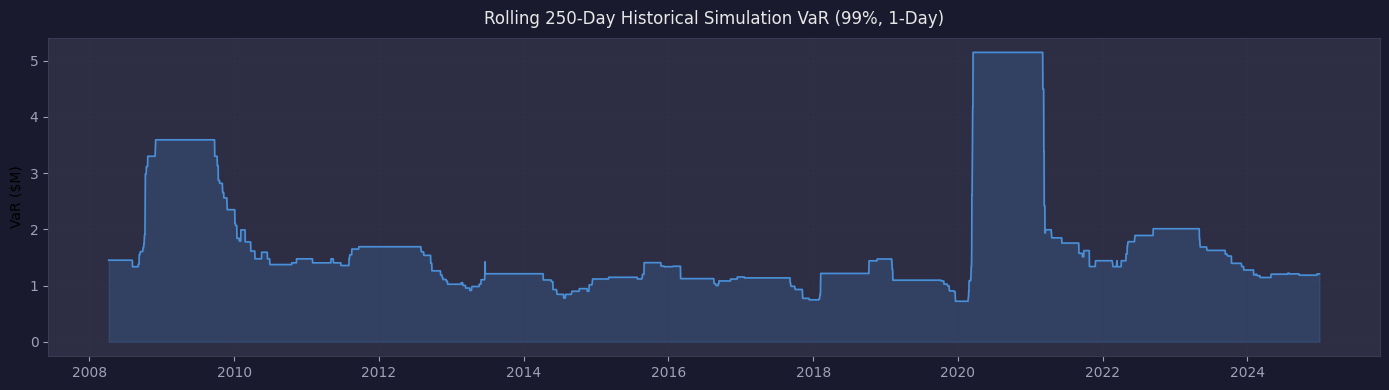

In [85]:
weights = pd.Series({t: PORTFOLIO[t]['weight'] for t in PORTFOLIO if t in returns.columns})
weights = weights / weights.sum()

# Daily portfolio P&L
pnl = returns[weights.index].dot(weights) * PORTFOLIO_VALUE

# Rolling 250-day VaR at 99%
var_series = pnl.rolling(HS_WINDOW).apply(
    lambda x: np.percentile(x, (1 - VAR_CONFIDENCE) * 100)
).dropna()
var_series = -var_series   # report as positive loss

hs_var_latest = var_series.iloc[-1]
print(f'Latest HS VaR (99%, 1-day): ${hs_var_latest:,.0f}  '
      f'({hs_var_latest/PORTFOLIO_VALUE*100:.2f}% of portfolio)')
print(f'Historical max VaR: ${var_series.max():,.0f}')
print(f'Historical min VaR: ${var_series.min():,.0f}')

fig, ax = plt.subplots(figsize=(14, 4))
ax.fill_between(var_series.index, var_series/1e6, alpha=0.2, color='#4a90d9')
ax.plot(var_series.index, var_series/1e6, color='#4a90d9', linewidth=1.2)
ax.set_title('Rolling 250-Day Historical Simulation VaR (99%, 1-Day)', pad=10)
ax.set_ylabel('VaR ($M)')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/hs_var_rolling.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Stressed VaR (Basel 2.5)

**Basel 2.5 requirement:** SVaR must be computed using a continuous 250-day period of significant financial stress relevant to the firm's portfolio. The stressed period must be **documented and justified**.

We use the 2008 Financial Crisis window. Optionally scan all windows to find the worst automatically.

In [86]:
# Fixed stress window: 2008 Financial Crisis
stress_ret = returns.loc[STRESS_START:STRESS_END, weights.index]
pnl_stress = stress_ret.dot(weights) * PORTFOLIO_VALUE
svar = -np.percentile(pnl_stress, (1 - VAR_CONFIDENCE) * 100)

print(f'Stress window: {STRESS_START} to {STRESS_END} ({len(stress_ret)} trading days)')
print(f'Stressed VaR (99%, 1-day): ${svar:,.0f}  ({svar/PORTFOLIO_VALUE*100:.2f}%)')
print(f'SVaR / HS VaR ratio: {svar/hs_var_latest:.2f}x')

# ── Optional: scan all windows ──────────────────────────────
print('\nScanning all 250-day windows for worst stress period...')
best_svar, best_start = 0, None
for i in range(len(pnl) - HS_WINDOW):
    w_pnl = pnl.iloc[i: i + HS_WINDOW]
    w_var = -np.percentile(w_pnl, (1 - VAR_CONFIDENCE) * 100)
    if w_var > best_svar:
        best_svar  = w_var
        best_start = pnl.index[i]
best_end = pnl.index[pnl.index.get_loc(best_start) + HS_WINDOW - 1]
print(f'Worst window: {best_start.date()} to {best_end.date()}  |  SVaR = ${best_svar:,.0f}')

Stress window: 2008-01-01 to 2008-12-31 (253 trading days)
Stressed VaR (99%, 1-day): $3,579,945  (3.58%)
SVaR / HS VaR ratio: 2.96x

Scanning all 250-day windows for worst stress period...
Worst window: 2019-03-22 to 2020-03-18  |  SVaR = $5,149,013


## 5. Monte Carlo VaR — Normal vs Student-t

In [87]:
tickers_in = [t for t in PORTFOLIO if t in returns.columns]
w_arr = np.array([PORTFOLIO[t]['weight'] for t in tickers_in])
w_arr = w_arr / w_arr.sum()

r     = returns[tickers_in].dropna()
mu    = r.mean().values
cov   = r.cov().values

rng   = np.random.default_rng(seed=42)

# (a) Multivariate Normal
sim_norm = rng.multivariate_normal(mu, cov, size=MC_SIMULATIONS)
pnl_norm = sim_norm.dot(w_arr) * PORTFOLIO_VALUE
var_norm = -np.percentile(pnl_norm, (1 - VAR_CONFIDENCE) * 100)

# (b) Multivariate Student-t — fit df per asset
df_list = []
for col in tickers_in:
    params = studentt.fit(r[col].values)
    df_list.append(params[0])
avg_df = np.mean(df_list)

L         = np.linalg.cholesky(cov)
z         = rng.standard_t(df=avg_df, size=(MC_SIMULATIONS, len(tickers_in)))
scale     = np.sqrt((avg_df - 2) / avg_df) if avg_df > 2 else 1.0
sim_t     = (z / scale).dot(L.T) + mu
pnl_t     = sim_t.dot(w_arr) * PORTFOLIO_VALUE
var_t     = -np.percentile(pnl_t, (1 - VAR_CONFIDENCE) * 100)

print(f'MC VaR (Normal):    ${var_norm:,.0f}  ({var_norm/PORTFOLIO_VALUE*100:.2f}%)')
print(f'MC VaR (Student-t): ${var_t:,.0f}  ({var_t/PORTFOLIO_VALUE*100:.2f}%)')
print(f'Fat-tail premium:   ${var_t-var_norm:,.0f}  ({(var_t/var_norm-1)*100:.1f}% higher)')
print(f'Average fitted df:  {avg_df:.2f}')

print('\nFitted degrees of freedom by asset:')
for ticker, df in zip(tickers_in, df_list):
    print(f'  {ticker}: df = {df:.2f}')

MC VaR (Normal):    $1,532,013  (1.53%)
MC VaR (Student-t): $3,813,353  (3.81%)
Fat-tail premium:   $2,281,340  (148.9% higher)
Average fitted df:  3.58

Fitted degrees of freedom by asset:
  SPY: df = 2.41
  QQQ: df = 2.84
  EEM: df = 2.96
  TLT: df = 6.56
  LQD: df = 3.20
  HYG: df = 1.98
  GLD: df = 3.61
  USO: df = 3.78
  FXE: df = 4.91


Here, we used averaged df to do Student-t simulation, which can cause problems.

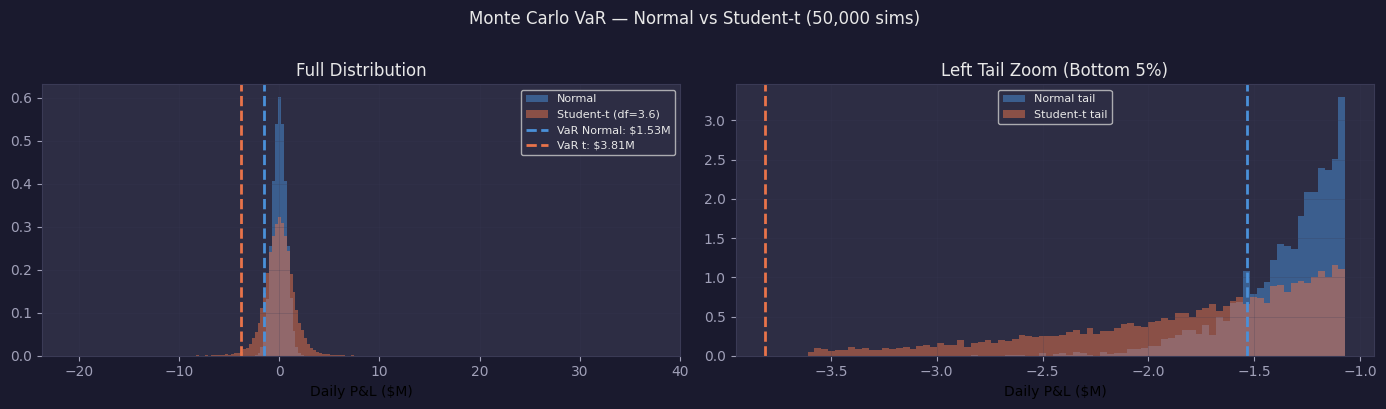

In [88]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
bins = np.linspace(min(pnl_norm.min(), pnl_t.min()),
                   max(pnl_norm.max(), pnl_t.max()), 200) / 1e6

axes[0].hist(pnl_norm/1e6, bins=bins, alpha=0.5, color='#4a90d9',
             density=True, label='Normal')
axes[0].hist(pnl_t/1e6, bins=bins, alpha=0.5, color='#e8734a',
             density=True, label=f'Student-t (df={avg_df:.1f})')
axes[0].axvline(-var_norm/1e6, color='#4a90d9', linewidth=2, linestyle='--',
                label=f'VaR Normal: ${var_norm/1e6:.2f}M')
axes[0].axvline(-var_t/1e6, color='#e8734a', linewidth=2, linestyle='--',
                label=f'VaR t: ${var_t/1e6:.2f}M')
axes[0].set_xlabel('Daily P&L ($M)')
axes[0].set_title('Full Distribution')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Zoom into left tail
tail_cut = np.percentile(np.concatenate([pnl_norm, pnl_t]), 1) / 1e6
tail_bins = np.linspace(tail_cut - 0.5, np.percentile(pnl_norm, 5)/1e6, 80)
axes[1].hist(pnl_norm/1e6, bins=tail_bins, alpha=0.5, color='#4a90d9',
             density=True, label='Normal tail')
axes[1].hist(pnl_t/1e6, bins=tail_bins, alpha=0.5, color='#e8734a',
             density=True, label='Student-t tail')
axes[1].axvline(-var_norm/1e6, color='#4a90d9', linewidth=2, linestyle='--')
axes[1].axvline(-var_t/1e6, color='#e8734a', linewidth=2, linestyle='--')
axes[1].set_xlabel('Daily P&L ($M)')
axes[1].set_title('Left Tail Zoom (Bottom 5%)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

fig.suptitle(f'Monte Carlo VaR — Normal vs Student-t ({MC_SIMULATIONS:,} sims)', y=1.01)
plt.tight_layout()
plt.savefig('output/mc_var_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Liquidity-Adjusted VaR (LVaR)

Standard VaR assumes **instantaneous liquidation**, which is unrealistic especially for less liquid asset classes. LVaR adds the estimated cost of unwinding each position:

$$\text{LVaR} = \text{VaR} + \sum_i \frac{1}{2} \cdot s_i \cdot w_i \cdot P \cdot \sqrt{T_i}$$

where $s_i$ = bid-ask spread, $w_i$ = weight, $P$ = portfolio value, $T_i$ = liquidation days.

In [89]:
rows = []
total_liq = 0
for ticker, info in PORTFOLIO.items():
    ac       = info['asset_class']
    w        = info['weight']
    notional = w * PORTFOLIO_VALUE
    spread   = BID_ASK_SPREADS.get(ac, 0.01)
    ldays    = LIQUIDATION_DAYS.get(ac, 1)
    lcost    = 0.5 * spread * notional * np.sqrt(ldays)
    total_liq += lcost
    rows.append({'Ticker': ticker, 'Asset Class': ac,
                 'Weight': f'{w*100:.1f}%',
                 'Notional ($M)': f'{notional/1e6:.1f}',
                 'Bid-Ask (%)': f'{spread*100:.3f}',
                 'Liq Days': ldays,
                 'Liq Cost ($K)': f'{lcost/1e3:.2f}'})

lvar = hs_var_latest + total_liq
lvar_df = pd.DataFrame(rows)
lvar_df.to_csv('output/lvar_breakdown.csv', index=False)

print(f'Base VaR (HS):     ${hs_var_latest:,.0f}')
print(f'Total Liq Cost:    ${total_liq:,.0f}')
print(f'LVaR:              ${lvar:,.0f}  ({lvar/PORTFOLIO_VALUE*100:.2f}%)')
print(f'Liquidity premium: {total_liq/hs_var_latest*100:.1f}% of base VaR')
lvar_df

Base VaR (HS):     $1,208,468
Total Liq Cost:    $687,139
LVaR:              $1,895,607  (1.90%)
Liquidity premium: 56.9% of base VaR


,Ticker,Asset Class,Weight,Notional ($M),Bid-Ask (%),Liq Days,Liq Cost ($K)
0,SPY,Equity,20.0%,20.0,0.500,1,50.00
1,QQQ,Equity,10.0%,10.0,0.500,1,25.00
2,EEM,EM Equity,5.0%,5.0,1.500,3,64.95
3,TLT,Rates,20.0%,20.0,0.300,1,30.00
4,LQD,Credit,10.0%,10.0,2.000,5,223.61
5,HYG,Credit,5.0%,5.0,2.000,5,111.80
6,GLD,Commodity,15.0%,15.0,1.000,2,106.07
7,USO,Commodity,10.0%,10.0,1.000,2,70.71
8,FXE,FX,5.0%,5.0,0.200,1,5.00


## 7. Backtesting — Basel Traffic-Light

Backtesting compares the VaR forecast against realised P&L. At 99% confidence over 250 days, we **expect ~2.5 exceptions**. Basel zones:
- 🟢 **Green** (0–4 exceptions): Model acceptable
- 🟡 **Yellow** (5–9): Investigate assumptions
- 🔴 **Red** (10+): Model likely flawed, capital multiplier increases

In [90]:
# ── Kupiec POF Test ─────────────────────────────────────────
def kupiec_pof(exceptions, n_obs, confidence):
    p = 1 - confidence
    if exceptions == 0:
        return {'LR': 0.0, 'p_value': 1.0, 'reject_H0': False}
    p_hat = exceptions / n_obs
    lr = -2 * (
        np.log((1-p)**(n_obs-exceptions) * p**exceptions)
        - np.log((1-p_hat)**(n_obs-exceptions) * p_hat**exceptions)
    )
    p_val = 1 - stats.chi2.cdf(lr, df=1)
    return {'LR': lr, 'p_value': p_val, 'reject_H0': p_val < 0.05}

# ── Christoffersen Independence Test ────────────────────────
def christoffersen(exc_series):
    hits = exc_series.astype(int).values
    n = len(hits)
    n00 = sum((hits[i]==0)&(hits[i+1]==0) for i in range(n-1))
    n01 = sum((hits[i]==0)&(hits[i+1]==1) for i in range(n-1))
    n10 = sum((hits[i]==1)&(hits[i+1]==0) for i in range(n-1))
    n11 = sum((hits[i]==1)&(hits[i+1]==1) for i in range(n-1))
    if (n01+n11)==0 or (n00+n10)==0:
        return {'LR_ind': 0.0, 'p_value': 1.0, 'clustering': False}
    pi_01 = n01/(n00+n01) if (n00+n01)>0 else 0
    pi_11 = n11/(n10+n11) if (n10+n11)>0 else 0
    pi    = (n01+n11)/(n00+n01+n10+n11)
    sl = lambda x: np.log(x) if x>0 else 0.0
    lr_ind = -2*(
        (n00+n10)*sl(1-pi)+(n01+n11)*sl(pi)
        - n00*sl(1-pi_01)-n01*sl(pi_01 if pi_01>0 else 1e-10)
        - n10*sl(1-pi_11)-n11*sl(pi_11 if pi_11>0 else 1e-10)
    )
    p_val = 1 - stats.chi2.cdf(lr_ind, df=1)
    return {'LR_ind': lr_ind, 'p_value': p_val, 'clustering': p_val<0.05}

# ── Run tests ───────────────────────────────────────────────
aligned = pd.DataFrame({'pnl': pnl, 'var': var_series}).dropna()
aligned['exception'] = aligned['pnl'] < -aligned['var']

n_exc = aligned['exception'].sum()
n_obs = len(aligned)
exp_exc = int((1-VAR_CONFIDENCE)*n_obs)

zone = 'GREEN' if n_exc<=4 else ('YELLOW' if n_exc<=9 else 'RED')
zone_emoji = {'GREEN':'🟢','YELLOW':'🟡','RED':'🔴'}[zone]

kup = kupiec_pof(n_exc, n_obs, VAR_CONFIDENCE)
chr = christoffersen(aligned['exception'])

print(f'Observations: {n_obs}  |  Exceptions: {n_exc}  (expected {exp_exc})')
print(f'Basel Traffic Light: {zone_emoji} {zone}')
print(f'Kupiec POF   — LR={kup["LR"]:.3f}, p={kup["p_value"]:.3f}, reject H0: {kup["reject_H0"]}')
print(f'Christoffersen — LR={chr["LR_ind"]:.3f}, p={chr["p_value"]:.3f}, clustering: {chr["clustering"]}')

Observations: 4212  |  Exceptions: 56  (expected 42)
Basel Traffic Light: 🔴 RED
Kupiec POF   — LR=4.187, p=0.041, reject H0: True
Christoffersen — LR=15.567, p=0.000, clustering: True


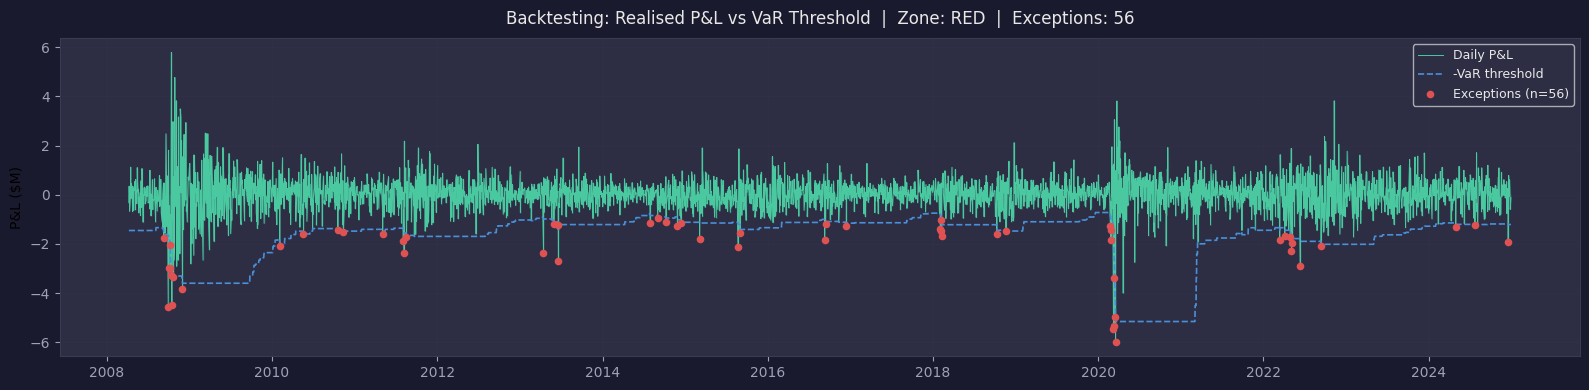

In [91]:
fig, ax = plt.subplots(figsize=(16, 4))
ax.fill_between(aligned.index, aligned['pnl']/1e6, alpha=0.15, color='#4ac9a0')
ax.plot(aligned.index, aligned['pnl']/1e6, color='#4ac9a0', linewidth=0.7, label='Daily P&L')
ax.plot(aligned.index, -aligned['var']/1e6, color='#4a90d9', linewidth=1.2,
        linestyle='--', label='-VaR threshold')
exc = aligned[aligned['exception']]
ax.scatter(exc.index, exc['pnl']/1e6, color='#e05252', s=20, zorder=5,
           label=f'Exceptions (n={n_exc})')
ax.legend(fontsize=9)
ax.set_ylabel('P&L ($M)')
ax.set_title(f'Backtesting: Realised P&L vs VaR Threshold  |  Zone: {zone}  |  Exceptions: {n_exc}', pad=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/backtest.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Full VaR Comparison & Summary

=== VaR Summary ===
         Method      VaR ($)  VaR ($M)  VaR (%)  vs HS VaR
         HS VaR 1.208468e+06     1.208    1.208      1.000
   Stressed VaR 3.579945e+06     3.580    3.580      2.962
MC VaR (Normal) 1.532013e+06     1.532    1.532      1.268
     MC VaR (t) 3.813353e+06     3.813    3.813      3.156
           LVaR 1.895607e+06     1.896    1.896      1.569


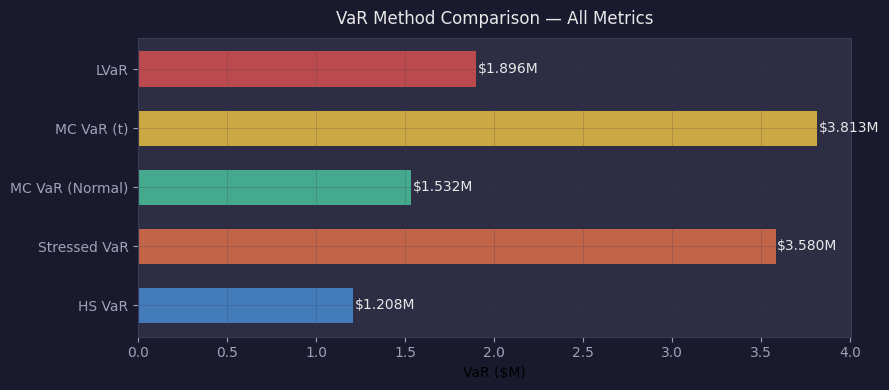

In [92]:
summary = pd.DataFrame({
    'Method':      ['HS VaR', 'Stressed VaR', 'MC VaR (Normal)', 'MC VaR (t)', 'LVaR'],
    'VaR ($)':     [hs_var_latest, svar, var_norm, var_t, lvar],
    'VaR ($M)':    [x/1e6 for x in [hs_var_latest, svar, var_norm, var_t, lvar]],
    'VaR (%)':     [x/PORTFOLIO_VALUE*100 for x in [hs_var_latest, svar, var_norm, var_t, lvar]],
    'vs HS VaR':   [1.0, svar/hs_var_latest, var_norm/hs_var_latest,
                    var_t/hs_var_latest, lvar/hs_var_latest],
})
summary = summary.round({'VaR ($M)': 3, 'VaR (%)': 3, 'vs HS VaR': 3})
print('=== VaR Summary ===')
print(summary.to_string(index=False))
summary.to_csv('output/var_summary.csv', index=False)

fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#4a90d9','#e8734a','#4ac9a0','#f5c842','#e05252']
bars = ax.barh(summary['Method'], summary['VaR ($M)'], color=colors, alpha=0.8, height=0.6)
for bar, val in zip(bars, summary['VaR ($M)']):
    ax.text(val+0.01, bar.get_y()+bar.get_height()/2,
            f'${val:.3f}M', va='center', color='#e8e8e8', fontsize=10)
ax.set_xlabel('VaR ($M)')
ax.set_title('VaR Method Comparison — All Metrics', pad=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('output/var_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

**Limitations:** 
- HS VaR assumes the future resembles the past — it will underestimate risk in novel stress regimes
- Correlations are assumed stable; empirically correlations spike in crises (correlation 1 effect)
- Single-period (1-day) VaR does not capture path dependency or gap risk
- ETF proxies may not perfectly replicate the asset classes in a real trading portfolio

In [93]:
print('=== All outputs saved to ./output/ ===')
for f in sorted(os.listdir('output')):
    path = os.path.join('output', f)
    size = os.path.getsize(path)
    print(f'  {f:40s}  {size/1024:.1f} KB')

=== All outputs saved to ./output/ ===
  backtest.png                              169.9 KB
  crisis_comparison.csv                     0.3 KB
  es_backtest.png                           48.5 KB
  garch_diagnostics.png                     129.2 KB
  garch_vs_hs_ghost.png                     382.6 KB
  hs_var_rolling.png                        46.4 KB
  lvar_breakdown.csv                        0.4 KB
  mc_var_distributions.png                  61.3 KB
  prices_raw.csv                            836.6 KB
  var_comparison.png                        40.9 KB
  var_es_ratio.png                          104.9 KB
  var_summary.csv                           0.3 KB
